In [42]:
import numpy as np
import pandas as pd
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt
import nltk
import seaborn as sns

In [76]:
df = pd.read_csv("all_big_company_news.csv")
df = df.drop_duplicates(subset=["News_Title"])
df["id"] = df.index

In [77]:
df.head()

,Date,News_Title,Sentiment_Reasoning,Sentiment,id
0,2026-03-19,S&P 500 Slides Gold Crashes As $100 Oil Stokes...,Declined 0.73% as tech stocks underperformed a...,-1.0,0
1,2026-03-19,3 of the Best Energy Stocks to Buy Right Now,Increased cost savings from Pioneer Natural Re...,1.0,1
2,2026-03-19,Crashing 51% 3 Reasons to Buy This Netflix Riv...,Stock is trading at a significant discount (51...,1.0,2
4,2026-03-19,Where Could Palantir Be in 3 Years? The Base C...,The article highlights strong commercial reven...,1.0,4
5,2026-03-19,Can AI Make Home Loans Cheaper? Palantir Think...,Strategic partnership announcement demonstrate...,1.0,5


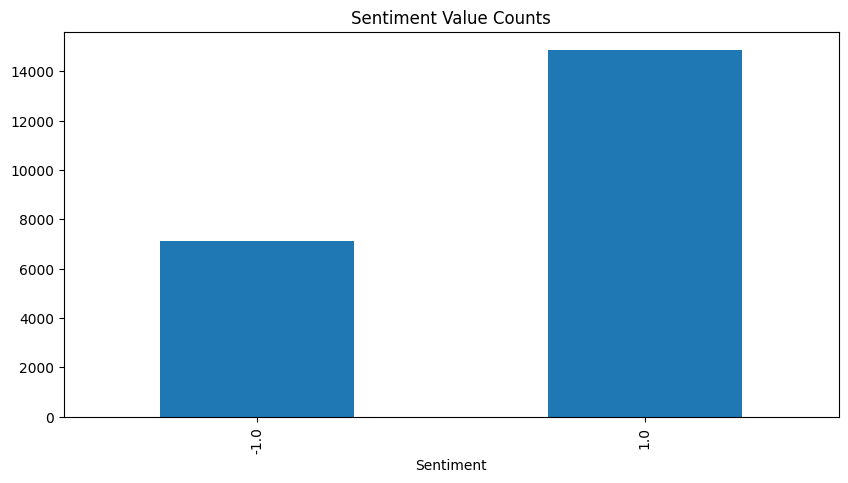

In [78]:
ax = df["Sentiment"].value_counts().sort_index().plot(kind="bar", title="Sentiment Value Counts", figsize=(10,5))
plt.show()

In [79]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Berkay\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [80]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

In [81]:
score_dic = {}
for idx, row in tqdm(df.iterrows(), total=len(df)):
    text = row["News_Title"]
    row_id = row["id"]
    score_dic[row_id] = sia.polarity_scores(text)

100%|██████████████████████████████████████████████████████████████████████████| 21968/21968 [00:04<00:00, 5323.14it/s]


In [82]:
vaders_s_df = pd.DataFrame(score_dic).T
vaders_s_df  = vaders_s_df.reset_index().rename(columns={"index":"id"})
vaders_s_df = vaders_s_df.merge(df, how="left")

In [87]:
vaders_s_df['vader_pred'] = vaders_s_df['compound'].apply(lambda x: 1 if x >= 0.05 else -1)

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(accuracy_score(vaders_s_df['Sentiment'], vaders_s_df['vader_pred']))
print(classification_report(vaders_s_df['Sentiment'], vaders_s_df['vader_pred']))

0.6099326292789512
              precision    recall  f1-score   support

        -1.0       0.44      0.78      0.56      7112
         1.0       0.83      0.53      0.65     14856

    accuracy                           0.61     21968
   macro avg       0.64      0.65      0.61     21968
weighted avg       0.71      0.61      0.62     21968



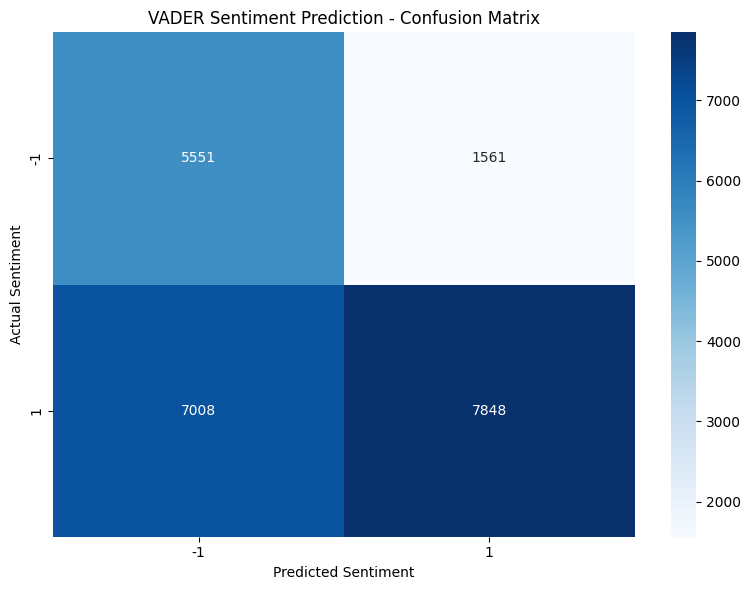

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(vaders_s_df['Sentiment'], vaders_s_df['vader_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[-1, 1], yticklabels=[-1, 1])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('VADER Sentiment Prediction - Confusion Matrix')
plt.tight_layout()
plt.savefig('vader_confusion_matrix.png', dpi=150)
plt.show()